<a href="https://colab.research.google.com/github/wlrjs1300-coder/AI_26/blob/main/08_02_%ED%95%A9%EC%84%B1%EA%B3%B1%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# 합성곱 신경망의 시각화
# 합성곱 층의 가중치와 특성 맵을 시각화하여 신경망이 이미지에서 어떤 것을 학습하는지 알아보자!

# 합성곱 신경망은 이미지에 있는 특징을 찾아 압축하는데 뛰어난 성능을 낸다.
# 합성곱 층이 이미지에서 어떤 것을 학습했는지 알아보기 위해
# 합성곱 층의 가중치와 특성 맵을 그림으로 시각화 하려고 한다.
# 케라스는 좀더 복잡한 모델을 만들 수 있도록 함수형 API를 제공한다.
# 합성곱 신경망의 체크포인트 파일을 사용한다.(최적의 에포크까지 훈련한 모델 파라미터를 저장하고 있다.)

# 가중치 시각화
# 합성곱 층은 여러개의 필터를 사용해 이미지에서 특징을 학습한다.
# 각 필터는 커널이라 부르는 가중치와 절편을 가지고 있다.
# 일반적으로 절편은 시각적으로 의미가 있지 않다.
# 가중치는 입력이 이미지의 2차원 영역에 적용되어 어떤 특징을 크게 두드러지게 표현하는 역할을 한다.
# 예를들어 아래 그림과 같은 둥근 모서리가 있는 영역에서 크게 활성화되고
# 그렇지 않은 영역에서는 낮을 값을 만든다.

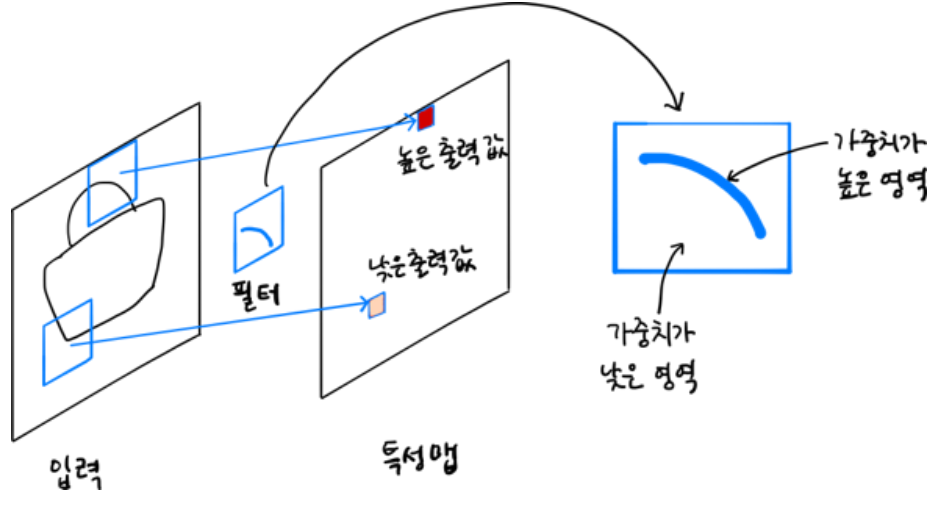

In [11]:
# 이 필터의 가운데 곡선 부분의 가중치 값은 높고 그 외 부분의 가중치 값은 낮다.
# 이렇게 해야 둥근 모서리가 있는 입력과 곱해져서 큰 출력을 만든다.

# 실행할 때마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고
# 텐서플로 연산을 만든다.
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

from tensorflow import keras
# 코랩에서 실행하는 경우 전에 만든
# 케라스 파일 best-cnn-model.keras 을 업로드하여 사용해보자!

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,580 (3.82 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 667,054 (2.54 MB)

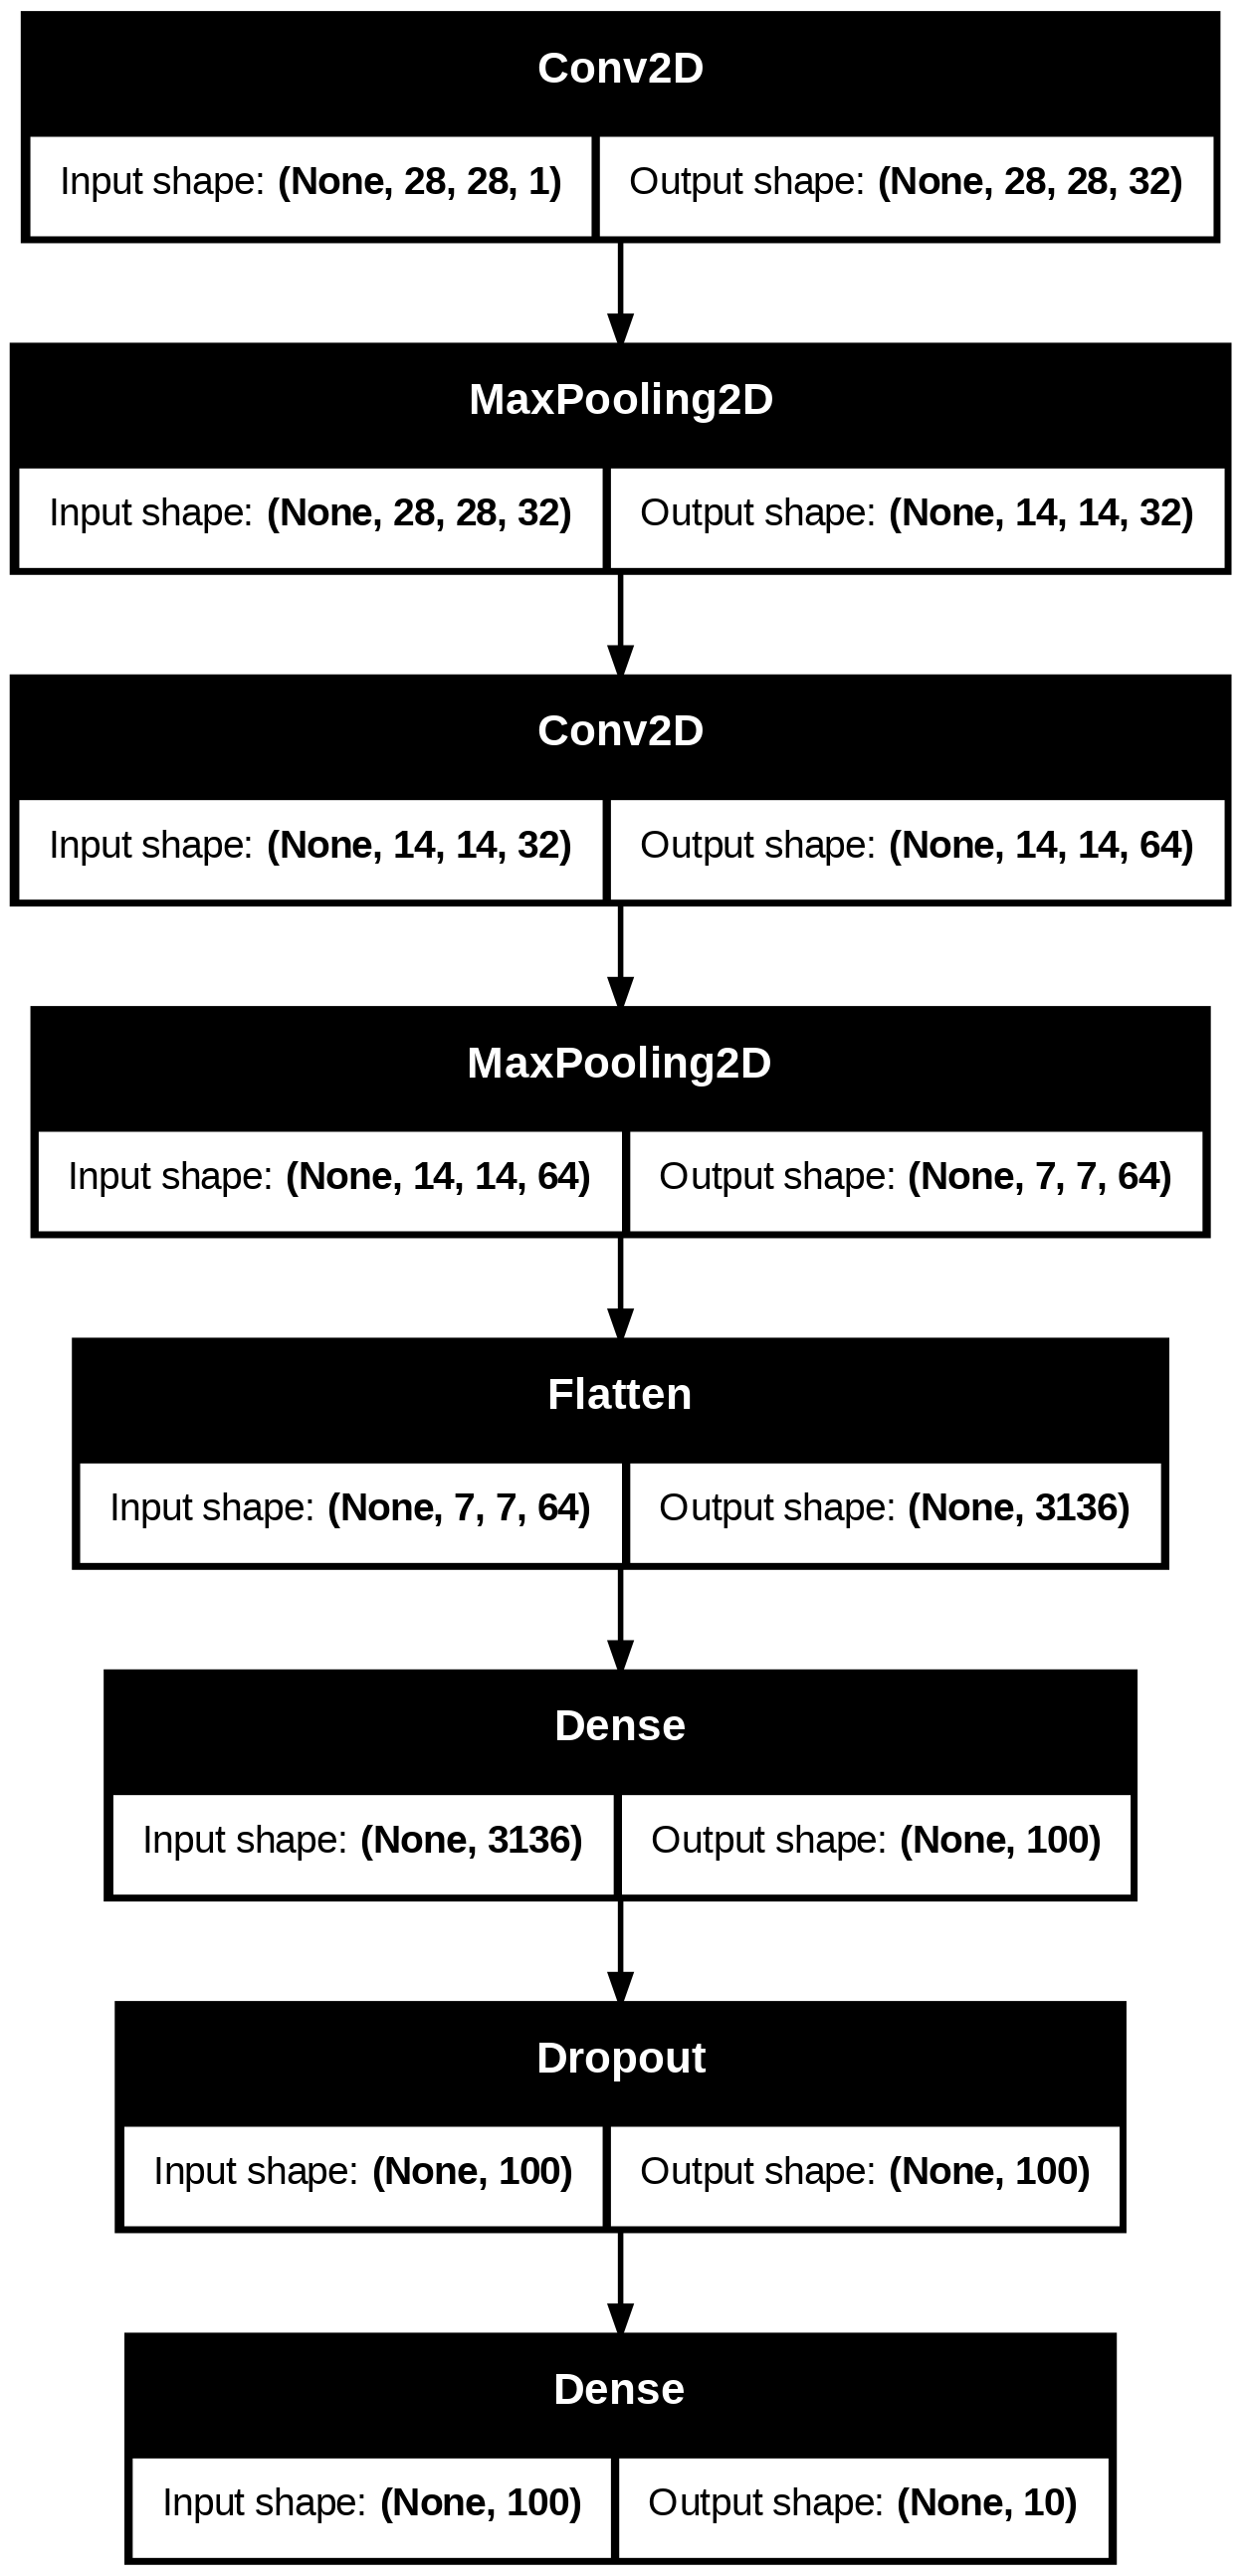

In [12]:
model = keras.models.load_model('best-cnn-model.keras') # 모델에 케라스 값을 불러온다.
model.layers
# model.layers 리스트에 전에 만들었던 Conv2D, MaxPooling2D 층이 번갈아 가면서 연속으로 나온다.
# Flatten층 -> Dense층 -> Dropout층 -> Dense 출력층도 보인다.
model.summary()
keras.utils.plot_model(model, show_shapes=True) # 입력과 출력 크기 표시

In [13]:
# 첫 번째 합성곱 층의 가중치를 알아보자!
# 각 층의 가중치와 절편은 각 층의 wieghts 속성에 있다.(리스트타입)
conv = model.layers[0] # 첫 번째 도장의 크기(커널, 필터)
print(conv.weights[0].shape, conv.weights[1].shape)
# (3, 3, 1, 32) (32,)
#    (원소)     (절편,)
# 전에 커널크기를 3x3으로 지정했다. 합성곱 층의 전달되는 입력의 깊이가 1이다.
# 필터 개수가 32개이고 필터마다 1개의 절편이 있음으로 (32,)가 된다.

(3, 3, 1, 32) (32,)


In [14]:
conv2 = model.layers[2] # 두 번째 도장의 크기(커널, 필터)
print(conv2.weights[0].shape, conv2.weights[1].shape)

(3, 3, 32, 64) (64,)


In [15]:
# weights 속성은 텐서플로의 다차원 배열인 Tensor 클래스의 객체이다.
# 다루기 쉽게 numpy() 메서드를 사용해 넘파일 배열로 변환한다.
conv_weights = conv.weights[0].numpy()
# 변환한 weights 속성의 평균(mean)과 표준편차(std)를 넘파이 메서드로 계산한다.
print(conv_weights.mean(), conv_weights.std())
# 결과값이 다를 수 있다.
# 평균은 0에 가깝고, 편차는 0.24정도이다.

-0.022672083 0.24381405


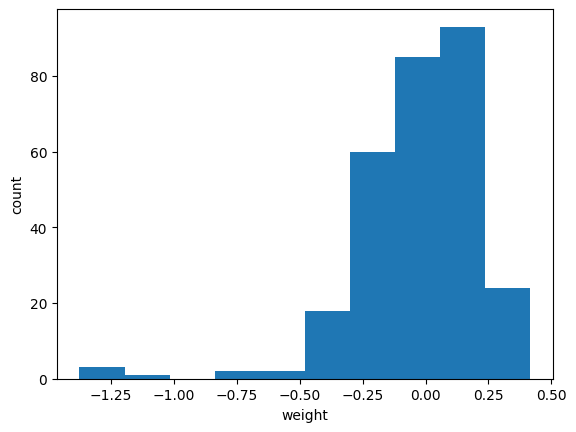

In [16]:
import matplotlib.pyplot as plt

# 이 가중치가 어떤 분포를 가졌는지 직관적으로 이해해보자!
# matplotlib의 histI() 함수에는 1차원 배열로 전달해야 한다. (히스토그램)
#       (conv_weights.reshape(-1,1)
plt.hist(conv_weights.reshape(-1,1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()
# 0을 중심으로 분표도를 확인할 수 있다.

In [17]:
print(conv_weights) # 9개의 리스트에 32개의 값이 나온다.

[[[[ 2.02088803e-01  1.43418983e-01  2.19320849e-01  2.29284391e-01
     1.20841131e-01 -1.61696643e-01  7.59740844e-02 -1.29516209e-02
    -1.84966177e-01 -1.30574688e-01 -3.13999325e-01 -2.37064481e-01
     3.21709886e-02  1.02949496e-02  2.37209365e-01 -1.06831527e+00
     1.49217084e-01  1.28653198e-01 -2.32722625e-01  3.59055810e-02
     4.12201658e-02  1.01128429e-01  9.12226620e-04  2.69055158e-01
     6.95954412e-02  1.08595088e-01  4.20145318e-02 -1.35924041e-01
     5.33467457e-02 -2.50822329e-03 -1.89365476e-01  2.87956763e-02]]

  [[ 3.28123540e-01  3.11297357e-01 -1.33119181e-01 -2.98786551e-01
    -2.34038830e-01 -1.89911216e-01 -3.33777117e-03 -8.77450854e-02
    -4.69493449e-01  2.21667171e-01  7.01824427e-02  1.18317991e-01
     3.62226404e-02  2.34399870e-01 -8.75496715e-02 -8.36041510e-01
    -1.31508067e-01 -1.13000624e-01  1.90599576e-01  7.77340233e-02
     1.88543543e-01  4.48442856e-03  1.67473733e-01  2.63023317e-01
     1.16015606e-01  2.63124973e-01  1.985211

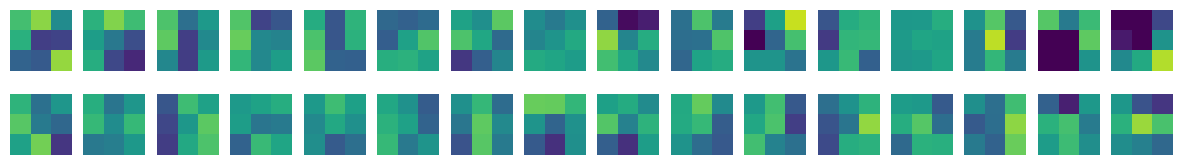

In [19]:
# 32개의 커널을 16개 씩 두줄에 출력 해보자!
fig,axs = plt.subplots(2, 16, figsize=(15,2))

# 2x16 = 32개의 그래프 영역을 만들고 순서대로 커널을 출력해보자!
for i in range(2): # i는 행의 인덱스 0~1
  for j in range(16): # j는 열의 인덱스 0~15
    axs[i,j].imshow(conv_weights[:,:,0,i*16+j], vmin=-0.5,vmax=0.5)
    axs[i,j].axis('off')
# 배열의 마지막 차원을 순회하면서 0~16+j 번째까지의 가중치 값을 차례대로 출력한다.
plt.show()
# 결과

In [21]:
# 합성곱을 이용한 도장으로는 눈으로 파악하기 힘들어 새로 만들어보자!

# 이번에는 훈련하지 않은 빈 합성곱 신경망을 만들어 본다.
# 이 합성곱 층의 가중치가 위에서 본 훈련한 가중치와 어떻게 다른지 그림으로 비교할 것이다.
no_training_model = keras.Sequential() # Sequential 클래스 모델을 만든다.

# Conv2D 층 하나 추가한다.
no_training_model.add(keras.layers.Conv2D(
    32, kernel_size=3, activation='relu', padding='same', input_shape=(28,28,1)))

# no_training_conv 변수에 Conv2D층의 가중치를 저장한다.
no_training_conv = no_training_model.layers[0]

# 동일하게 (3,3) 커널을 가진 필터를 32개 사용한다.
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


In [22]:
# 이 가중치의 평균과 표준편차를 확인해보자!
no_training_weights = no_training_conv.weights[0].numpy() # 넘파이 배열로 만든다.

print(no_training_weights.mean(), no_training_weights.std())
#               (평균)                    (표준편차)

-0.0009919289 0.085228495


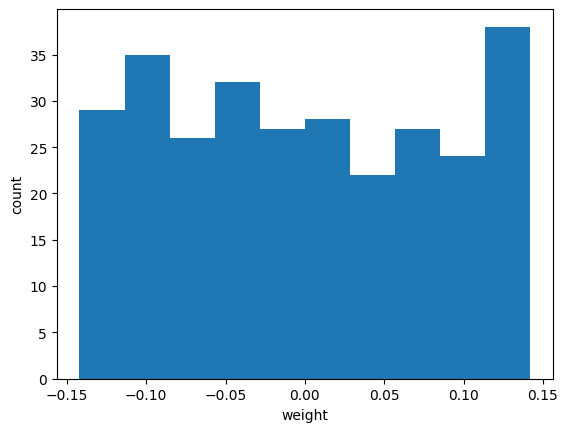

In [23]:
# 이 가중치 배열을 히스토그램으로 출력해보자!
plt.hist(no_training_weights.reshape(-1,1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()
# 비교적 고른 분포를 보인다.

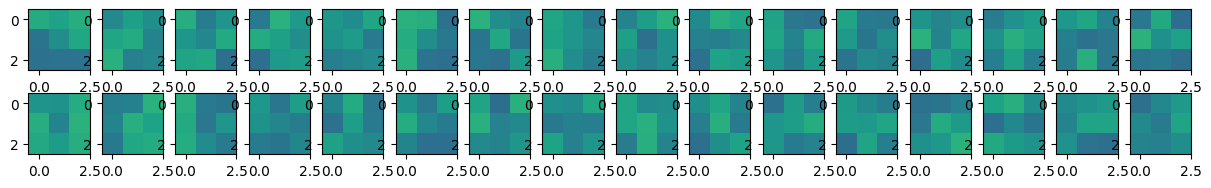

In [25]:
# imshow() 함수를 이용해서 그림으로 출력해보자!
fig, axs = plt.subplots(2, 16, figsize=(15,2))

for i in range(2):
  for j in range(16):
    axs[i,j].imshow(no_training_weights[:,:,0,i*16+j], vmin=-0.5, vmax=0.5)

plt.show()
# 가중치가 밋밋하게 표현됐다
# 위 훈련된 이미지와 비교해보면
# 분류 정확도를 높이기 위해서 유용한 패턴을 학습했다는 사실이 나온다.

In [ ]:
# 함수형 API : 케라스의 내장형 함수
# 케라스의 Sequential 클래스는 층을 차례대로 쌓은 모델을 만든다.
# 딥러닝에는 좀더 복잡한 모델이 많이 있다.

# 이 때 사용하는 것이 함수형 API이다.
# 함수형 API는 케라스의 Model 클래스를 사용하여 모델을 만든다.

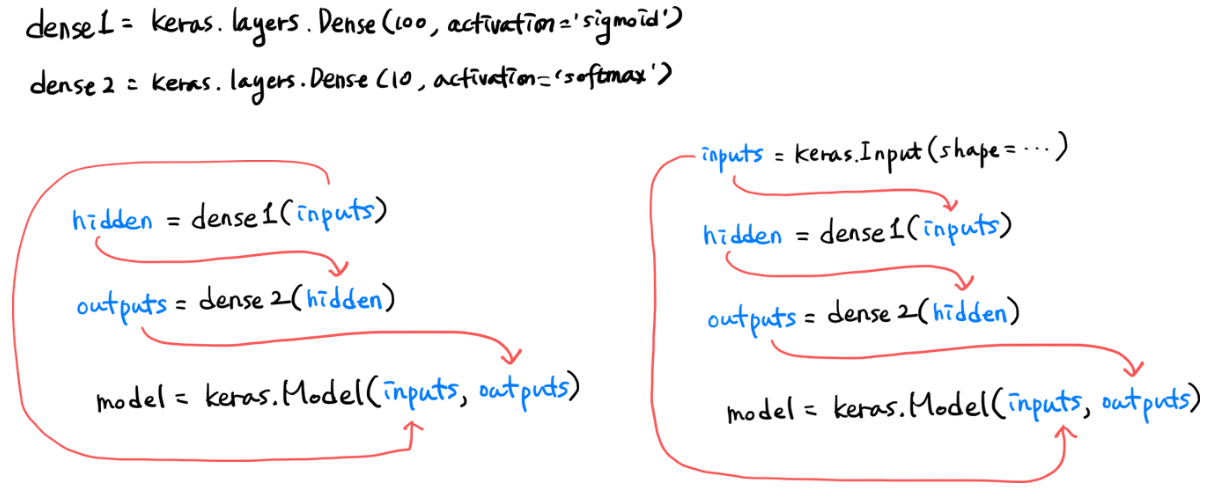

In [ ]:
# Dense 층 2개으로 이루어진 완전 연결 신경망을 함수형 API로 구현한 것이다.
# 2개의 Dense 층 객체를 만들어 keras.Model()에 파라미터로서 제공한다.
# 입력에서 출력까지 층을 호출한 결과를 계속 이어주고 Model 클래스에 입력과 최종 출력을 지정한다.
# 여기 나온 input=keras.input()은 plot_model() 함수로 모델의 층을 도식화 했을 때
# InputLayer 클래스가 처음 나온 것으로
# Sequential 클래스는 InputLayer 클래스를 자동으로 추가하고 호출해준다.

# Model 클래스에서는 수동을 만들어서 호출해야한다.

# 전체를 합쳐보면 위의 그림처럼 체인으로 동작한다.
# 입력에서 출력까지 연결하고 마지막에 Model 클래스에 입력과 출력을 지정하여 모델을 만든다.
# 이렇게 모델을 만들게 되면 중간에 다양한 형태의 층을 연결할 수 있다.
# inputs = keras.input(shape=(784,))

# dense1 = keras.layers.Dense(100, activation='sigmoid')
# dense2 = keras.layers.Dense(10, activation='softmax')

# hidden = dense1(inputs)
# outputs = dense2(hidden)

# model = keras.Model(inputs,outputs)

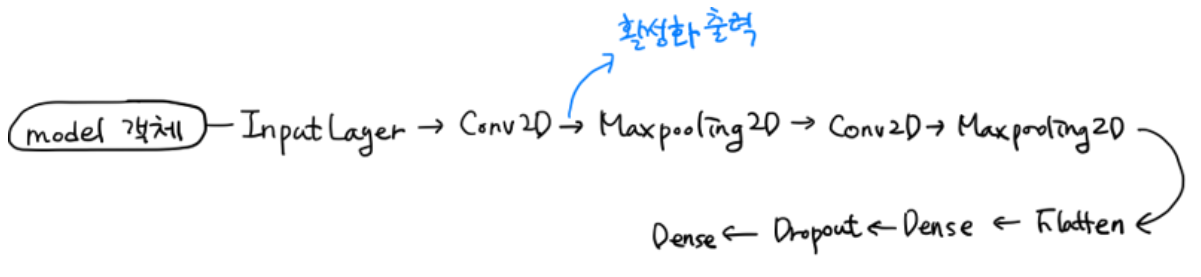

In [ ]:
# 함수형 API가 필요한 이유

# 하나의 모델은 여러 레이어로 구성된다.
# Input → Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Dropout → Dense

# CNN에서는 Conv2D를 지나면서 이미지의 특징(feature)이 추출된다.
# 이때 Conv2D의 출력(feature map)을 따로 확인하고 싶은 경우가 있다.

# Sequential 모델은 보통 입력 → 마지막 출력만 쉽게 사용할 수 있다.

# 하지만 함수형 API를 사용하면
# 모델의 입력과 중간 레이어의 출력을 직접 지정할 수 있다.

# 그래서 Input부터 첫 번째 Conv2D의 출력까지만 사용하는
# 새로운 모델을 만들 수 있다.

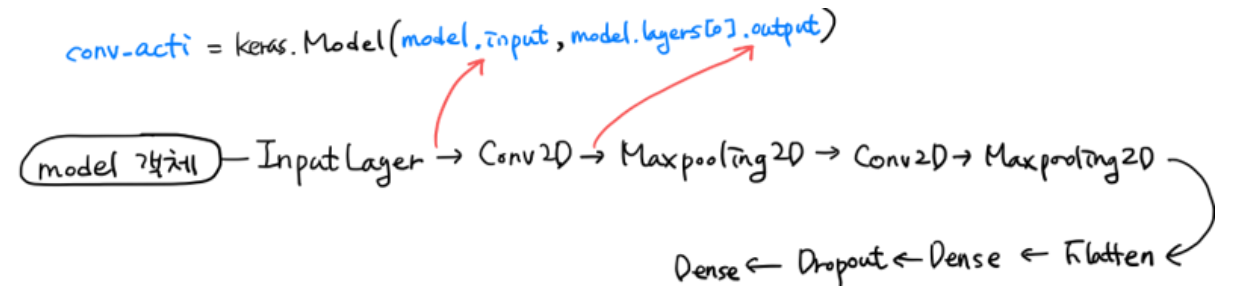

In [26]:
# model.predict() 메서드를 호출하면 마지막 층까지 모든 계산을 수행한 후
# 최종 출력을 반환한다.

# 하지만 우리가 필요한 것은 첫 번째 Conv2D 층에서 출력한 특성 맵이다.
# 첫 번째 Conv2D 층에서 출력한 특성 맵은 Conv2D 객체의 output 속성에서 얻을 수 있다.
# -> model.layer[0].output

# 모델의 입력은 model.inputs로 얻을 수 있다.

print(model.inputs)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_1>]


In [27]:
# 이제 model.input 과 model.layers[0].output을 연결하는 새로운 conv_acti 모델을 만들 수 있다.

conv_acti = keras.Model(model.inputs, model.layers[0].output)

# model 객체의 predict() 메서드를 호출하면 최종 출력층의 확률을 보여준다.
# -> model.predict(val_scaled[0:1])

# 하지만 conv_acti의 predict() 메서드를 호출하면 첫 번째 Conv2D의 출력을 보여준다.
# -> conv_acti.predict(inputs)

In [28]:
# 특성 맵 시각화
# 케라스로 패션 MNIST 데이터 셋을 읽은 후 훈련 세트에 있는 첫 번째 샘플을 그려본다.
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


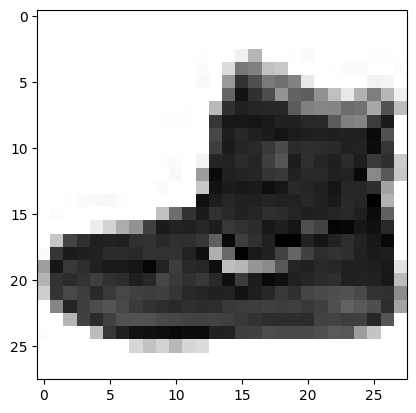

In [29]:
# 첫 번째 샘플을 출력한다.
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [30]:
# 첫 번째 이미지 1개를 선택 (predict()는 항상 배치 차원을 포함한 입력을 기대함)
# → 그래서 [0]이 아니라 [0:1] 슬라이싱을 사용

# 선택한 이미지를 CNN 입력 형태로 변환
# (784,) → (28, 28, 1) : 28x28 흑백 이미지 형태로 변경

# 픽셀 값을 0~1 범위로 만들기 위해 255로 나누는 전처리 수행
inputs = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0

# conv_acti 모델에 이미지를 넣어 첫 번째 Conv2D 층의 출력(feature map)을 계산
feature_maps = conv_acti.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


In [31]:
print(feature_maps.shape) # maps의 크기를 확인
# (1, 28, 28, 32) 1장의 이미지, 28x28 크기, 필 32개

(1, 28, 28, 32)


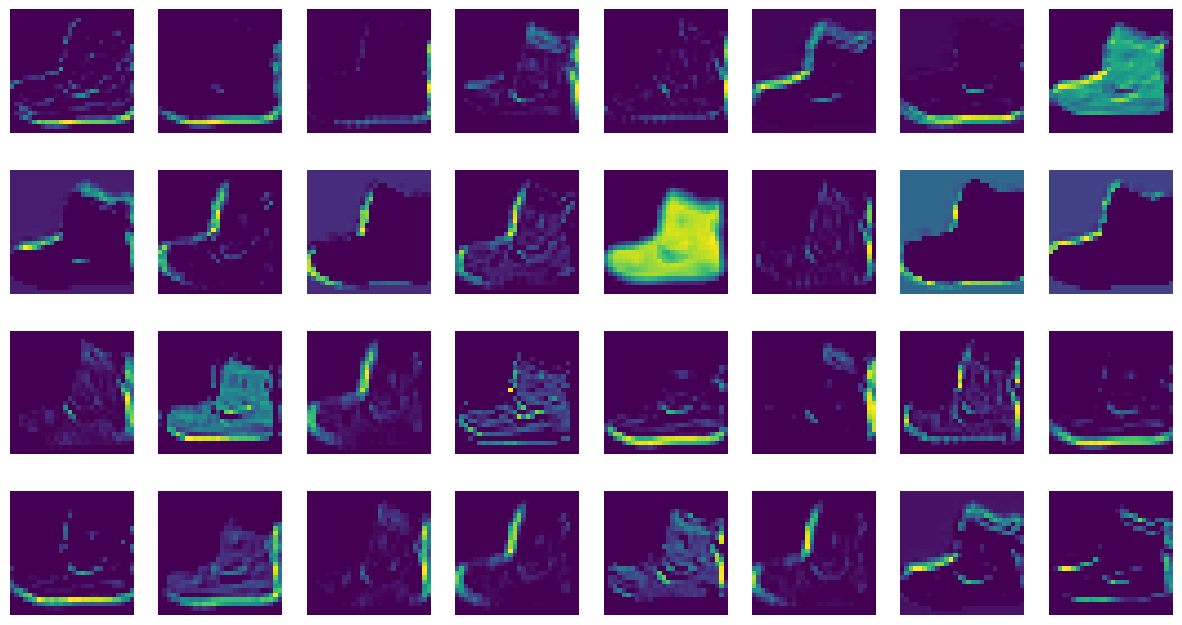

In [32]:
# Conv2D 층은 same padding과 32개의 필터를 사용했기 때문에
# 출력 특성맵의 크기는 (28, 28, 32)가 된다.
# 여기서 32는 필터 개수 → 즉 32개의 특성맵이 만들어진다는 의미

# predict()의 출력은 항상 배치 차원을 포함한다.
# 이미지 1장을 넣었기 때문에 전체 출력 크기는 (1, 28, 28, 32)가 된다.

# 32개의 특성맵을 화면에 출력하기 위해
# 4행 8열(총 32칸)의 그래프를 생성
fig, axs = plt.subplots(4, 8, figsize=(15,8))

# 각 위치에 특성맵 하나씩 출력
for i in range(4):
    for j in range(8):
        # feature_maps[0] → 첫 번째 이미지
        # :,: → 28x28 공간 정보
        # i*8 + j → 32개의 필터 중 하나 선택
        axs[i, j].imshow(feature_maps[0, :, :, i*8 + j])

        # 축 정보는 필요 없으므로 제거
        axs[i, j].axis('off')

# 모든 특성맵 출력
plt.show()

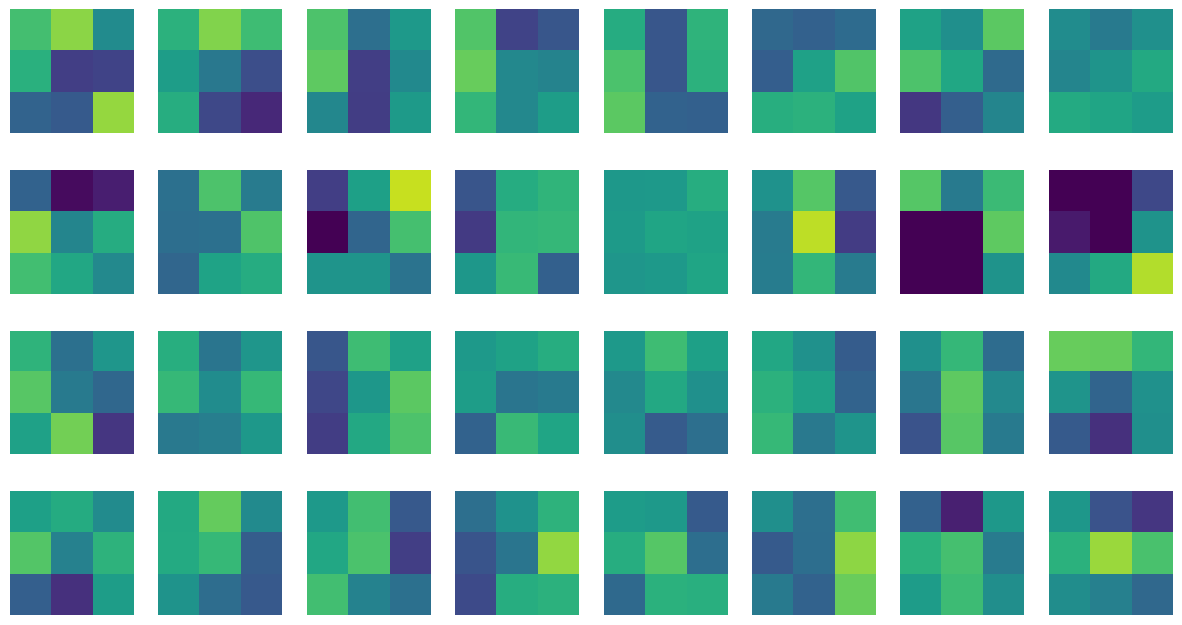

In [33]:
# 특성 맵과 비교를 해본다.
fig, axs = plt.subplots(4,8,figsize=(15,8))

for i in range(4):
  for j in range(8):
    axs[i,j].imshow(conv_weights[:,:,0,i*8+j],vmin=-0.5,vmax=0.5)
    axs[i,j].axis('off')

plt.show()

In [35]:
# 두 번째 Conv2D 층이 만든 특성맵도 같은 방법으로 확인할 수 있다.
# 두 번째 Conv2D 층의 가중치 shape : (3, 3, 32, 64)
# → 3x3 필터, 입력 채널 32개, 필터 64개
# → 따라서 64개의 특성맵이 생성된다.

# 기존 모델의 입력과 두 번째 Conv2D 층의 출력을 연결하여
# 두 번째 합성곱 결과를 출력하는 새로운 모델을 만든다.
conv2_acti = keras.Model(model.inputs, model.layers[2].output)

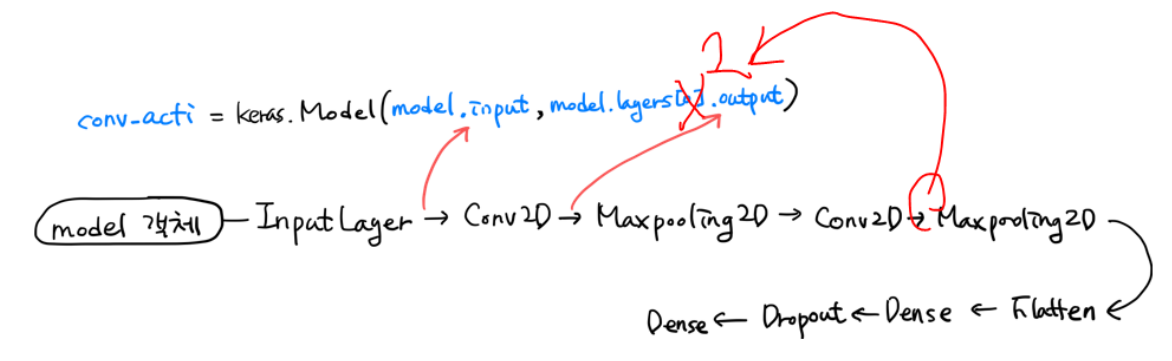

In [36]:
# 첫 번째 이미지를 선택해 conv2_acti 모델에 입력
# reshape(-1, 28, 28, 1) → CNN 입력 형태 (배치, 높이, 너비, 채널)로 변환
# /255.0 → 픽셀 값을 0~1 범위로 정규화

feature_maps = conv2_acti.predict(train_input[0:1].reshape(-1, 28, 28, 1) / 255.0)

# 첫 번째 MaxPooling 층에서 이미지 크기가 절반으로 줄어듦
# 28x28 → 14x14

# 두 번째 Conv2D 층은 64개의 필터를 사용하므로
# 64개의 특성맵(feature map)이 생성됨

# 따라서 출력 shape는
# (배치크기, 높이, 너비, 필터개수) = (1, 14, 14, 64)

print(feature_maps.shape)  # (1, 14, 14, 64)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
(1, 14, 14, 64)


In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,580 (3.82 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 667,054 (2.54 MB)

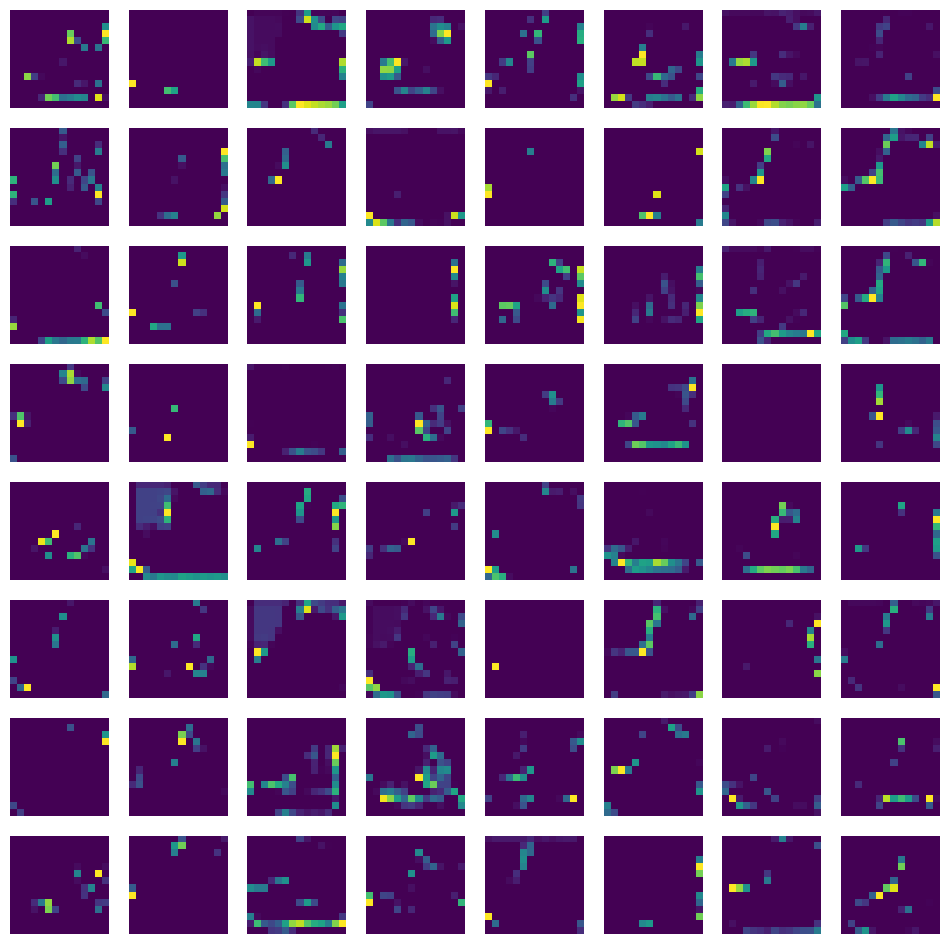

In [38]:
# 64개의 특성 맵을 8개씩 나누어 imshow()로 그려봄
fig, axs = plt.subplots(8, 8, figsize=(12,12))

for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')

plt.show()

In [ ]:
# 두 번째 Conv2D 층에서 만든 특성맵은 사람이 눈으로 이해하기 어렵다.

# 두 번째 Conv2D 층의 필터 크기는 (3,3,32)이다.
# → 앞에서 생성된 32개의 특성맵을 동시에 사용해 새로운 특징을 계산한다.

# 즉 두 번째 합성곱 층의 한 필터는
# 이전 층에서 만든 32개의 특성맵을 이용해 하나의 새로운 특성맵을 만든다.

# 이렇게 계산된 결과는 (14,14,64) 크기의 특성맵이 된다.
# 하지만 이 특성맵이 이미지의 어떤 부분을 감지하는지
# 사람 눈으로 직관적으로 이해하기는 어렵다.

# CNN에서는 앞쪽 합성곱 층이
# 선, 모서리 같은 기본적인 시각 정보를 감지하고

# 뒤쪽 합성곱 층은
# 앞에서 추출한 특징들을 조합해 더 복잡하고 추상적인 특징을 학습한다.

# 이런 과정을 통해 최종적으로
# 10개의 클래스(패션 아이템)를 구분할 수 있게 된다.

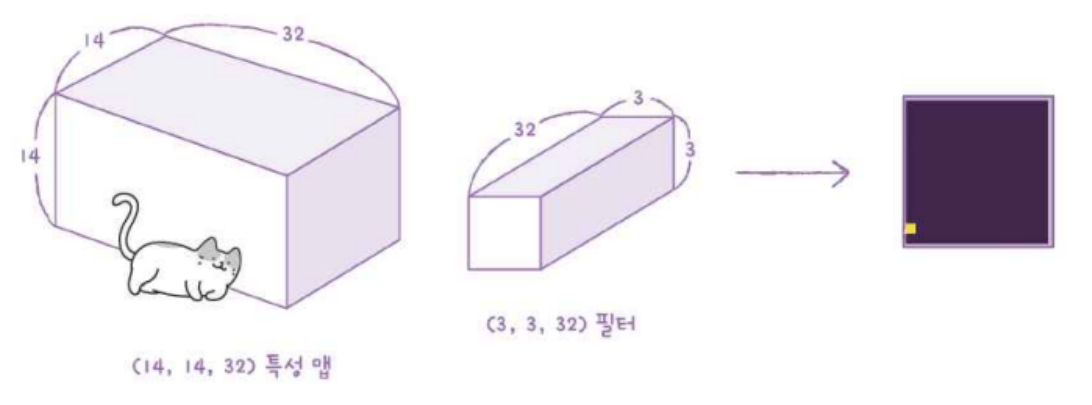